With topspin (signs for $C_L$ have to be reversed and $C_L=0$ for flat since no lifting force), we have the following two equations from Brody et al. as well as $|C_L|=\frac{1}{2+|v|/|v_{spin}|}$ from P385.

\begin{align}
    \frac{dv_x}{dt} &= -kv(C_dv_x-C_Lv_y) \\
    \frac{dv_y}{dt} &= kv(-C_Lv_x-C_dv_y)-g
\end{align}

With $k=\frac{\rho \pi R^2}{2m}$ where $\rho$ is air density, $R$ is the tennis ball's radius, and $m$ is its mass.

We infer from the $g$ component for $v_y$ being negative that upwards is seen as the positive direction on the vertical axis and that $\theta$ is the angle at which the ball is flying upward from the horizontal plane.

The parameters involved can be set below:

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt

# constants, all with respect to kilogram, meter, and seconds when applicable
c_d = 0.55 # drag coefficient assumed to be constant but actually changes with spin, source: P385 intial value Brody et al.
rho = 1.29 # air density, source: NASA (earthdata.nasa.gov/topics/atmosphere/atmospheric-pressure/air-mass-density)
r = 0.033 # ball radius, source: 6.6 cm diameter within acceptable bounds of 2023 ITF
m = 0.057 # ball mass, source: P387 example, within acceptable bounds of 2023 ITF
k = rho*math.pi*r**2/(2*m)
g = 9.8

# variable(s)
# average spin velocity depends on whether shot was forehand or backhand
# range from atp site rpm stat (reddit.com/r/tennis/comments/11y5avk/indian_wells_2023_topspin_rates_and_groundstroke)
v_spin = 2500 # unit rotations per minute, 2500 for both forehand and backhand, positive(negative) for topspin(backspin)
v_spin = v_spin/60*2*math.pi*r
# initial conditions, set for each shot, also change vectorfield chosen and timepoints below accordingly
v0 = 29 # m/s
theta0 = 0.15 # radians
impact_h = 1 # height off ground where ball is hit (positve value) (2.7m~9ft for serves and overhead smash, ow 1m)

With $v_x = v\cos\theta$ and $v_y = v\sin\theta$, we take derivatives with respect to $t$:

\begin{align}
    v'\cos \theta - v(\sin \theta) \theta ' &= -kv(C_dv\cos\theta-C_Lv\sin\theta) \dots (1) \\
    v'\sin \theta + v(\cos \theta) \theta ' &= kv(-C_Lv\cos\theta-C_dv\sin\theta) - g \dots (2)
\end{align}

$(1)\cos\theta+(2)\sin\theta \\ \Rightarrow v' = -kC_dv^2-g\sin\theta \dots (3)$

$(2)\cos\theta-(1)\sin\theta \\ \Rightarrow \theta' = -kC_Lv-\frac{g}{v}\cos\theta = -\frac{kv}{2+v/v_{spin}}-\frac{g}{v}\cos\theta \dots (4)$

With backspin instead of topspin, only the signs for $C_L$ are reversed, resulting in no change for $(3)$ and a slight change of signs for $(4)$ to be $\theta' = kC_Lv-\frac{g}{v}\cos\theta = \frac{kv}{2+v/v_{spin}}-\frac{g}{v}\cos\theta$.

When the ball is flat, we have $C_L=0$, still yielding no change for $(3)$, while $(4)$ becomes simply $\theta' = -\frac{g}{v}\cos\theta$.

In [2]:
from scipy.integrate import odeint # scipy-cookbook.readthedocs.io/items/CoupledSpringMassSystem.html

In [3]:
def topspin_equations(w, t, p):
    """
    Equations for topspin trajectory above in vectorfield form for ODEINT
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), -k*v/(2+v/abs(v_spin))-g*math.cos(theta)/v]
    return f

def backspin_equations(w, t, p):
    """
    Equations for backspin trajectory above in vectorfield form for ODEINT
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), k*v/(2+v/abs(v_spin))-g*math.cos(theta)/v]
    return f

def flat_equations(w, t, p):
    """
    Equations for flat trajectory above in vectorfield form for ODEINT
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), -g*math.cos(theta)/v]
    return f

#### pre-bounce trajectory

In [4]:
# Set-up from the cookbook example
# ODE solver parameters
# adjust stoptime and numpoints for each shot
abserr = 1.0e-8
relerr = 1.0e-6
stoptime = 10 # long so don't have to adjust manually
numpoints = 2500
# Create the time samples for the output of the ODE solver
t = [stoptime * float(i) / (numpoints - 1) for i in range(numpoints)]
# Pack up the parameters and initial conditions:
p = [k, c_d, v_spin, g]
w0 = [v0, theta0]
if v_spin > 0:
    vectorfield = topspin_equations
elif v_spin < 0:
    vectorfield = backspin_equations
else:
    vectorfield = flat_equations

In [5]:
# Call the ODE solver.
pre_bounce = odeint(vectorfield, w0, t, args=(p,), atol=abserr, rtol=relerr)

Next step is to visualize and extract the proportions of distance at height 1 meter to obtain the hitting windows. For each time point's $v$ and $\theta$, we move the ball forward $vt\cos\theta$ and upwards $vt\sin\theta$ (which can be negative) where $t$ is stoptime/numpoints above.

In [6]:
unit_t = stoptime/(numpoints-1)
x_pre = [0]*(numpoints+1)
y_pre = [0]*(numpoints+1)
for i in range(numpoints):
    x_pre[i+1] = x_pre[i] + unit_t*pre_bounce[i,0]*math.cos(pre_bounce[i,1])
    y_pre[i+1] = y_pre[i] + unit_t*pre_bounce[i,0]*math.sin(pre_bounce[i,1])
cutoff_bounce = np.argmax(np.array(y_pre) < -impact_h)
x_pre = x_pre[:cutoff_bounce]
y_pre = y_pre[:cutoff_bounce]

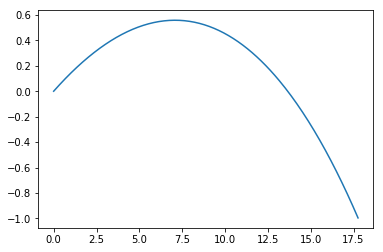

In [7]:
plt.plot(x_pre, y_pre)

#### post-bounce trajectory

We also want the trajectory of the ball after the bounce. In our model, a bounce uniformly results in an accumulation of topspin speed of 40 rps (Brody et al. used this for demonstrational purposes in P217). With our additional simplification of the exit angle being the same as the entry angle, the ball also has its speed $v$ reduced by a factor of the coefficient of restitution.

In [8]:
# customizable constants
cor = 0.8
spin_acc_rps = 40
v_1, theta_bounce = pre_bounce[cutoff_bounce,:] # speed and angle into bounce
# Get new spin speed and initial speed, angle
theta_bounce = -theta_bounce
v_2 = v_1*cor
v_spin2 = v_spin + spin_acc_rps*2*math.pi*r
if v_spin2 > 0:
    vectorfield = topspin_equations
elif v_spin2 < 0:
    vectorfield = backspin_equations
else:
    vectorfield = flat_equations
p2 = [k, c_d, v_spin2, g]
w0_2 = [v_2, theta_bounce]

In [9]:
post_bounce = odeint(vectorfield, w0_2, t, args=(p2,), atol=abserr, rtol=relerr)

In [10]:
x_post = [0]*(numpoints+1)
x_post[0] = x_pre[-1] # distance covered pre-bounce
y_post = [0]*(numpoints+1)
y_post[0] = -impact_h # shift ground level to be -1 to align with pre-bounce height
for i in range(numpoints):
    x_post[i+1] = x_post[i] + unit_t*post_bounce[i,0]*math.cos(post_bounce[i,1])
    y_post[i+1] = y_post[i] + unit_t*post_bounce[i,0]*math.sin(post_bounce[i,1])
cutoff_end = np.argmax(np.array(y_post[1:]) < -impact_h)
x_traj = x_pre+x_post[:cutoff_end]
y_traj = y_pre+y_post[:cutoff_end]

#### extracting fractions of pre-bounce distance for windows

Here we often have the ball not bouncing back to 1 meter high. Our fix is for hitting windows to be taken on a shot-by-shot basis during shot initialization, with the additional simplification that for a given shot, the ball's height when hit (mostly 1 meter) will be fixed and we ignore the discrepancy between this fixed height and the height of the window from the previous shot.

In [39]:
# extration parameters
h1 = 0.75 # window height
h2 = 1.25
h3 = 1.85 # player height for reference

Text(25.1, -1, 'GS')

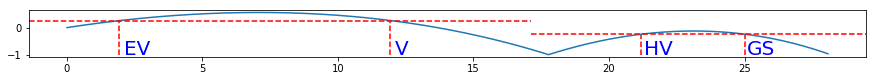

In [73]:
plt.figure().set_figwidth(15)
# plt.figure().set_figheight(50)
plt.plot(x_traj,y_traj)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.axhline(y=h1-impact_h, color='r', linestyle='--',xmin=0.6)
plt.axhline(y=h2-impact_h, color='r', linestyle='--',xmax=0.6)
# plt.axhline(y=h3-impact_h, color='b', linestyle='--')
plt.vlines([1.91489,11.93573,21.18537,25.03642],ymin=-impact_h,ymax=[h2-impact_h,
                                                                     h2-impact_h,
                                                                     h1-impact_h,
                                                                     h1-impact_h],linestyles='--',color='r')
ax.text(2.1,-impact_h,"EV",fontsize=20,color='blue')
ax.text(12.1,-impact_h,"V",fontsize=20,color='blue')
ax.text(21.3,-impact_h,"HV",fontsize=20,color='blue')
ax.text(25.1,-impact_h,"GS",fontsize=20,color='blue')

Note fractions extracted should be with respect to horizontal distance from impact to anchor (cutoff_bounce). Fractions for HV and GS should be smaller than 1 as they are for horizontal distance covered post-bounce.

In [24]:
# cutoff_bounce = np.argmax(np.array(y_pre) < -impact_h)
x_traj[cutoff_bounce] # the unit 1 for the fractions

17.763610683223618

In [42]:
# np.argwhere(np.array(y_traj)>h1-impact_h) # 246, 315
# np.argwhere(np.array(y_traj)>h2-impact_h) # 17, 118

In [15]:
x_traj[250]/x_traj[cutoff_bounce]

1.205682503088777

In [54]:
x_traj[315]

25.036427362618443

Text(25.1, 0, 'GS')

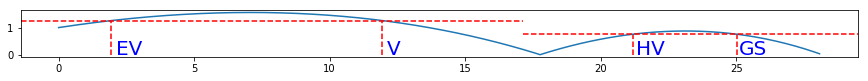

In [75]:
y_traj_d = [h + impact_h for h in y_traj]
plt.figure().set_figwidth(15)
# plt.figure().set_figheight(50)
plt.plot(x_traj,y_traj_d)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.axhline(y=h1, color='r', linestyle='--',xmin=0.6)
plt.axhline(y=h2, color='r', linestyle='--',xmax=0.6)
# plt.axhline(y=h3-impact_h, color='b', linestyle='--')
plt.vlines([1.91489,11.93573,21.18537,25.03642],ymin=0,ymax=[h2,h2,h1,h1],linestyles='--',color='r')
ax.text(2.1,0,"EV",fontsize=20,color='blue')
ax.text(12.1,0,"V",fontsize=20,color='blue')
ax.text(21.3,0,"HV",fontsize=20,color='blue')
ax.text(25.1,0,"GS",fontsize=20,color='blue')